<a href="https://colab.research.google.com/github/harryCarpio/CGTALNEjercicioClase3/blob/main/optuna_interactive_grupo8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Optuna:** Advanced search and interactive visualizations

#### **Imports**

In [ ]:
%pip install optuna nbformat "plotly>=6.1.1" "kaleido==0.2.1" ipywidgets scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.7 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
import optuna
import time
import numpy as np
import pandas as pd
import os

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score

#### **Data**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arshid/iris-flower-dataset")

print("Path to dataset files:", path)

100%|██████████| 0.99k/0.99k [00:00<00:00, 2.20MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/arshid/iris-flower-dataset/versions/1


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Find the CSV file in the downloaded path
csv_path = os.path.join(path, 'IRIS.csv')
iris_df = pd.read_csv(csv_path)

# Separate features and target
X = iris_df.drop(columns=['species'])

# Convert categorical target to numeric
le = LabelEncoder()
y = le.fit_transform(iris_df['species'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Iris dataset loaded, target encoded numerically, and split successfully.")
print(f"Classes mapped: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Iris dataset loaded, target encoded numerically, and split successfully.
Classes mapped: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [ ]:
display(iris_df.sample(5))

iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
6,4.6,3.4,1.4,0.3,Iris-setosa
31,5.4,3.4,1.5,0.4,Iris-setosa
134,6.1,2.6,5.6,1.4,Iris-virginica
19,5.1,3.8,1.5,0.3,Iris-setosa
13,4.3,3.0,1.1,0.1,Iris-setosa


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


#### **Helpers**

In [ ]:
def count_parameters(model):
    total = 0
    for coef in model.coefs_:
        total += coef.size
    for intercept in model.intercepts_:
        total += intercept.size
    return total

def estimate_flops(model):
    flops = 0
    for coef in model.coefs_:
        flops += 2 * coef.size # Multiply and add. Bias adds one more operation per neuron, but we can ignore it for estimation.
    return flops

#### **Objective**

In [ ]:
def objective(trial):
    # Expanded architectures to include more variety and new requested layers
    hidden_layers = trial.suggest_categorical(
        "hidden_layer_sizes", [
            (50,), (100,), (50, 50), # original
            (150, 150), # double-layer network
            (50, 25, 10) # deep three-layer network
        ]
    )
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)

    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation=activation,
            alpha=alpha,
            max_iter=1000, # Increased for convergence
            early_stopping=True,
            random_state=42
        )
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average="macro")

    mlp = model.named_steps["mlpclassifier"]
    n_params = count_parameters(mlp)
    flops = estimate_flops(mlp)

    return f1, n_params, flops

#### **Run Study**

In [ ]:
# Re-creating the study to incorporate the new search space
study = optuna.create_study(
    directions=["maximize", "minimize", "minimize"]
)

study.optimize(objective, n_trials=100)

[I 2026-05-05 03:59:34,208] A new study created in memory with name: no-name-21ef4601-2160-41b3-a1b7-79e7f332328d
/tmp/ipykernel_2151/4110379881.py:3: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  hidden_layers = trial.suggest_categorical(
/tmp/ipykernel_2151/4110379881.py:3: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  hidden_layers = trial.suggest_categorical(
/tmp/ipykernel_2151/4110379881.py:3: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  hidden_layers = trial.suggest_categorical(
/tmp/ipykernel_2151/4110379881.py:3: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int,

#### **Interactive Visualizations**

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"
import plotly.graph_objects as go

# Pareto front
fig = optuna.visualization.plot_pareto_front(study)
fig.update_layout(
    title="Pareto Front: F1 Score vs Parameters vs FLOPs",
    scene=dict(
        xaxis_title="F1 Score (maximize)",
        yaxis_title="Parameters (minimize)",
        zaxis_title="FLOPs (minimize)"
    )
)
fig.show()

In [ ]:
import plotly.io as pio
pio.renderers.default = 'colab'

fig = optuna.visualization.plot_optimization_history(study, target=lambda t: t.values[0], target_name="F1 Score")
fig.show()

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"

# Parameter importance
fig = optuna.visualization.plot_param_importances(study)
fig.show()

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"

# Parallel coordinate plot
fig = optuna.visualization.plot_parallel_coordinate(
    study,
    target=lambda t: t.values[0],
    target_name="F1 Score"
)
fig.show()

#### **Task**

1. Increase trials (50-100)
2. Add more architectures
3. Analyze the visualization graphs of your search (critical thinking)

## Análisis crítico

En esta práctica exploramos el uso de Optuna, un framework de código abierto para la optimización automática de hiperparámetros, es flexible, permite la visualización de resultados y habilita la integración con librerías de machine learning. Además, usamos el submódulo Plotly.io de Plotly para renderizar gráficos interactivos como HTML.

### Frente de pareto

| ParetoFront_100T | ParetoFront_50T | ParetoFront_30T |
|:---:|:---:|:---:|
| 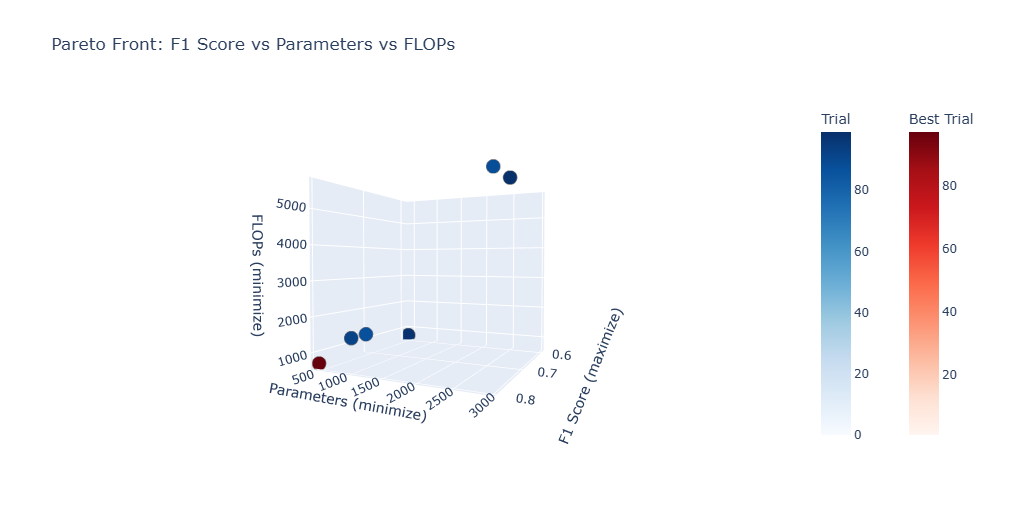 | 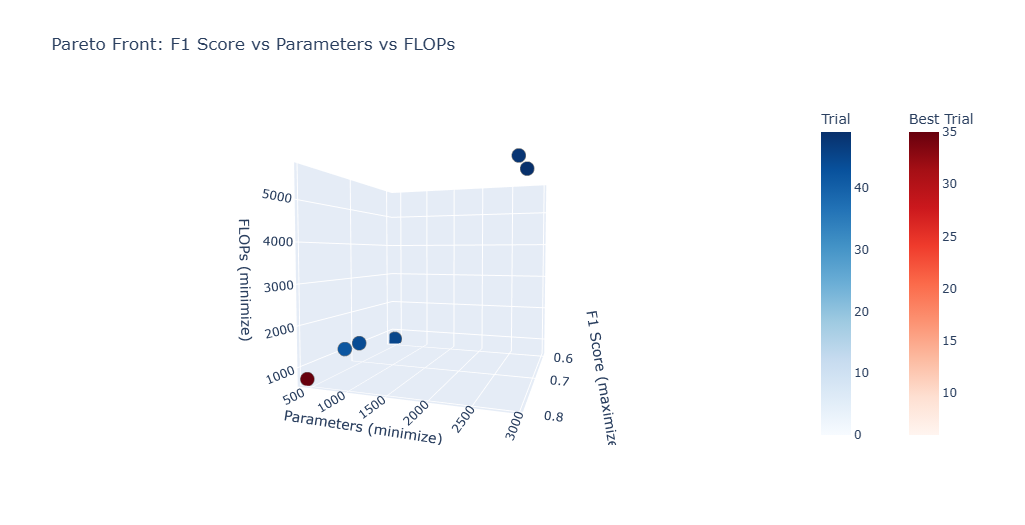 | 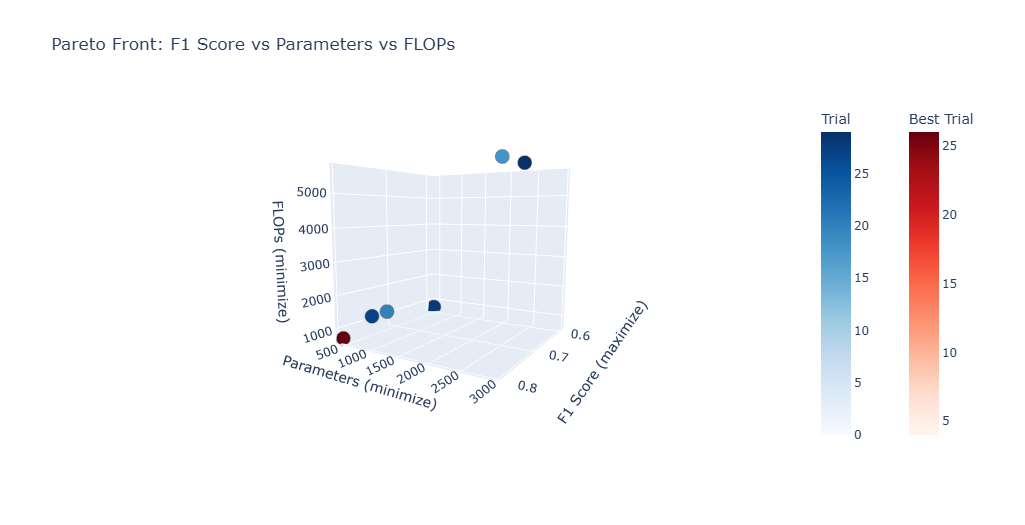 |

Ejecutamos Optuna con 30, 50 y 100 experimentos, en cada intento, Optuna:
1. Muestrea un conjunto de hiperparámetros del espacio de búsqueda
2. Evalúa la función objetivo con esos hiperparámetros
3. Registra los resultados para guiar el siguiente intento

Esto permite evaluar los resultados después de una optimización multiobjetivo.

Consideramos que el aspecto más interesante de la comparativa de diferentes valores de `n_trials` es la diferencia de intensidad de colores de los puntos obtenidos. Visualemente los puntos se ubican en las mismas coordenadas xyz (F1 Score, Parameters y FLOPs) pero diferiern en la intesidad de los colores, esto indica que los valores se obtuvieron en diferentes iteraciones, mientras más iteraciones o experimentos se realizan, más tarda Optuna en encontrar los valores optimos.



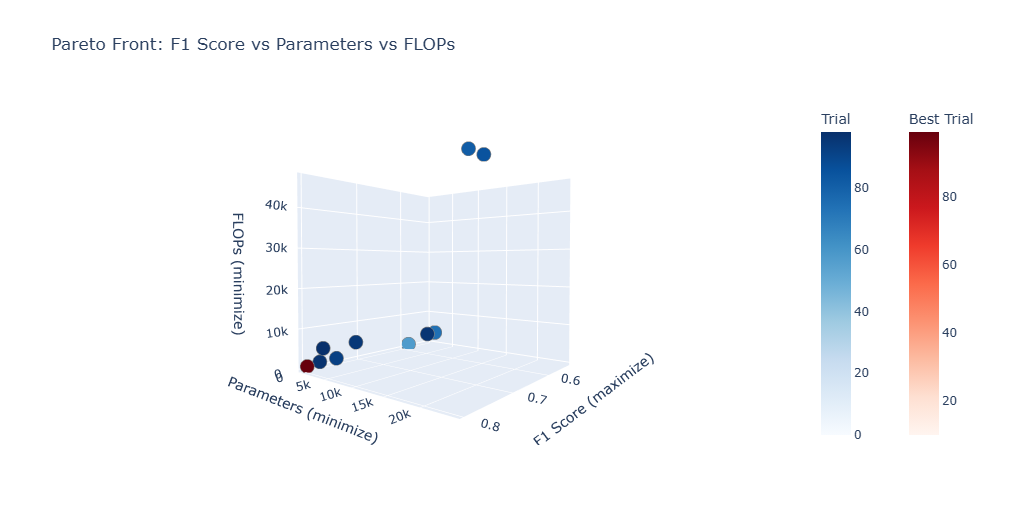

En la imagen previa vemos cómo al incluir más arquitecturas, el efecto es que se mantienen los valores para las arquitecturas originales y se agregan los correspondientes para las nuevas. El mejor experimiento permanece inmutable, es decir, las arquitecturas agregadas resultaron peores que las originales.



### Eficiencia arquitectónica
Aunque arquitecturas más profundas (las agregadas) aumentan significativamente el número de parámetros, no siempre producen un aumento proporcional en el F1 Score para el conjunto de datos Iris, lo que sugiere que modelos más simples son suficientes para este nivel de complejidad.

### Importancia de parámetros

#### 30 experimentos
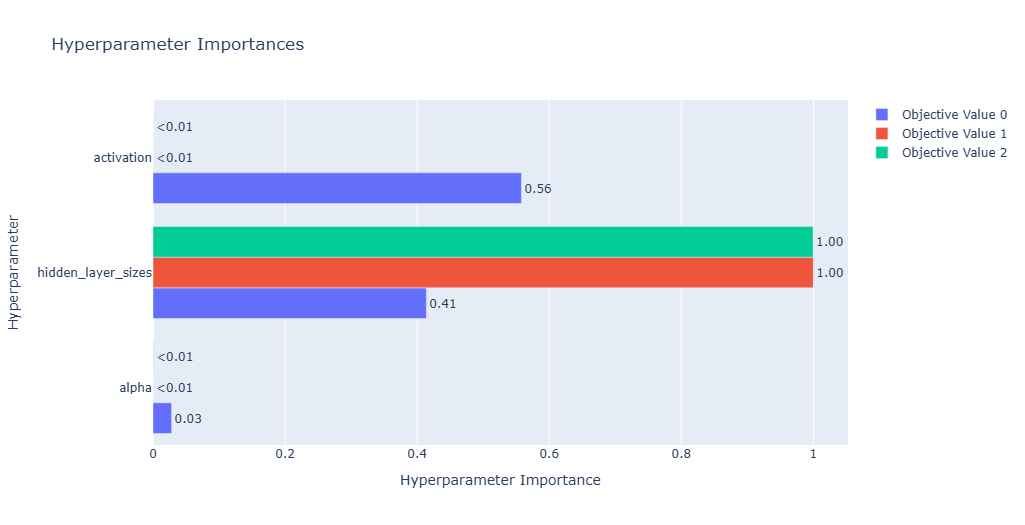

#### 50 experimentos
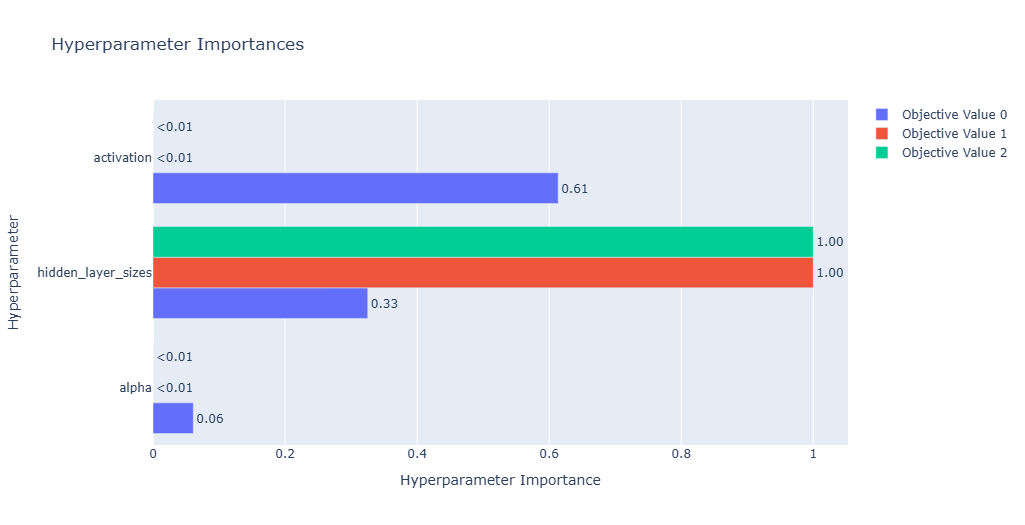



#### 100 experimentos (con arquitecturas extendidas)
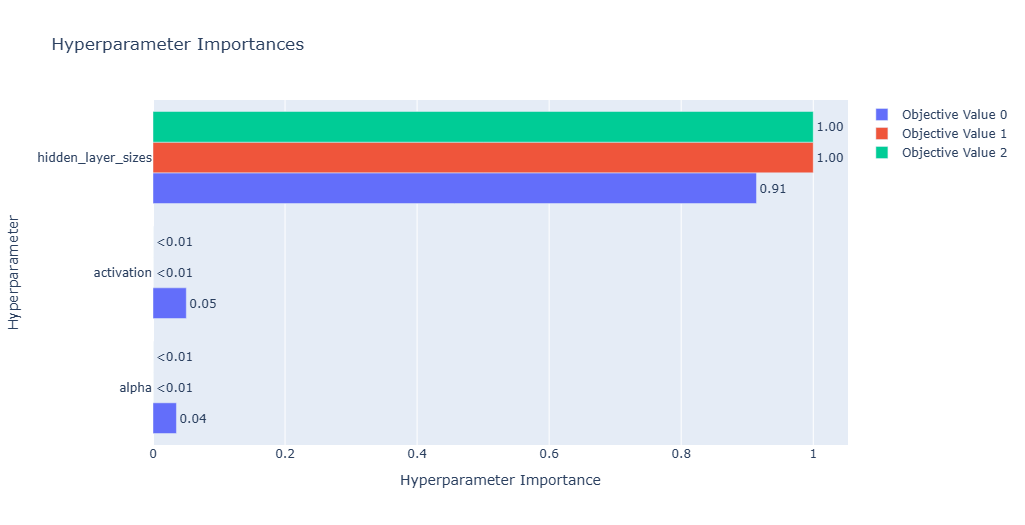

Podemos concluir que `hidden_layer_sizes` y `alpha` (regularización) tienen el impacto más significativo en el rendimiento del modelo, mientras que las funciones de activación (relu vs. tanh) suelen tener un efecto secundario.

### Patrones de convergencia
El historial de optimización indica que Optuna explora de manera efectiva el espacio de búsqueda al principio y comienza a explotar las regiones más prometedoras (por ejemplo, rangos específicos de alpha) a medida que el número de pruebas se acerca a 100.

#### Historial de optimización con 30 experimentos

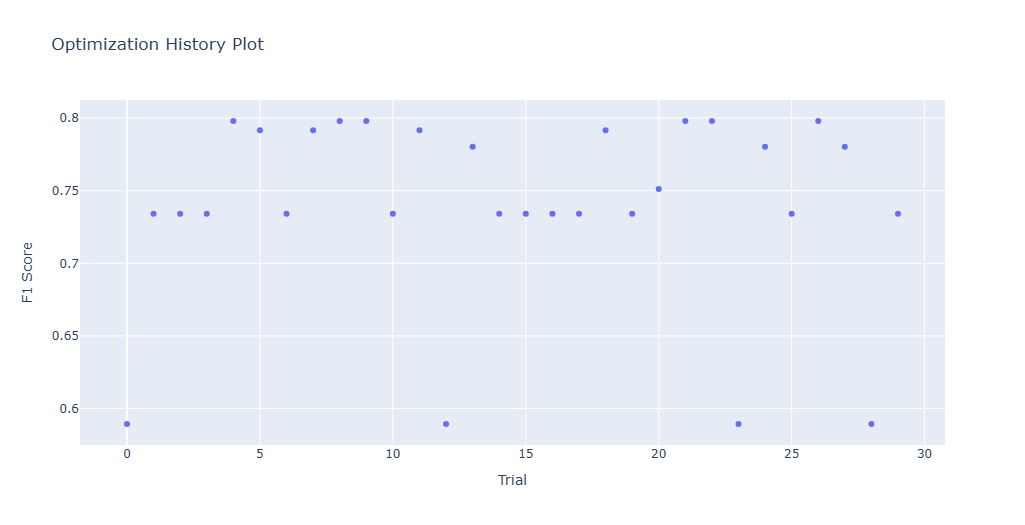

#### Historial de optimización con 50 experimentos

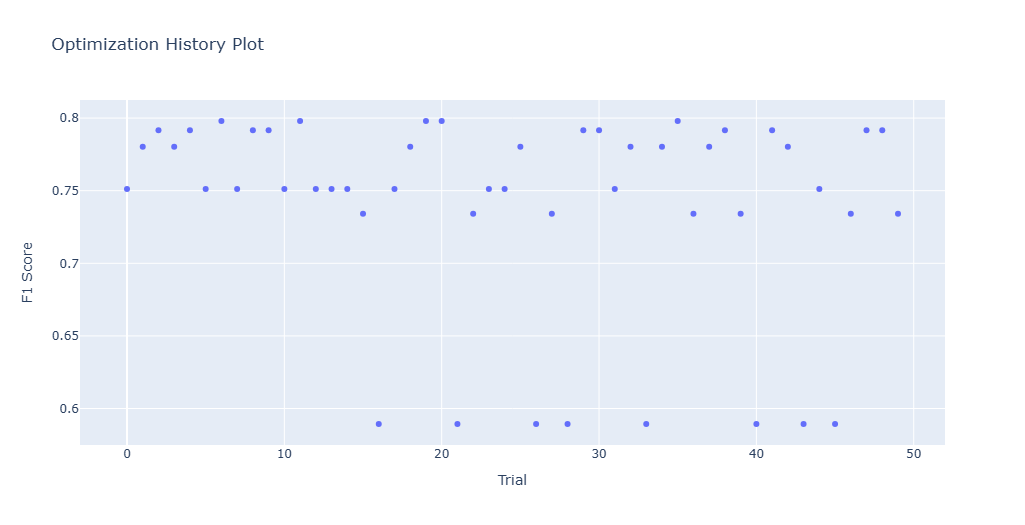

#### Historial de optimización con 100 experimentos

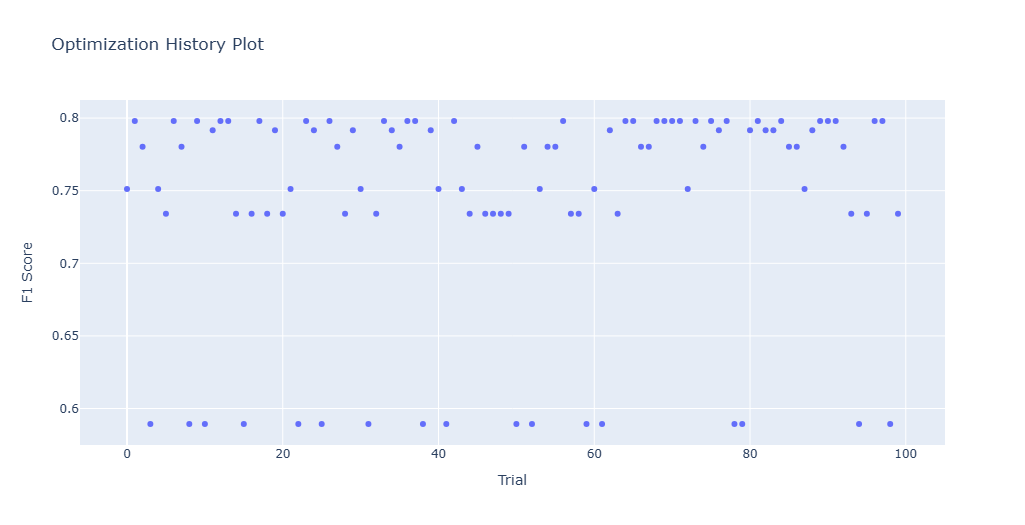

### Sensibilidad a los hiperparámetros
Los gráficos de coordenadas paralelas sugieren que se pueden alcanzar puntuaciones F1 altas en diversas arquitecturas siempre que el valor de alpha se ajuste correctamente, lo que destaca la importancia de la regularización para prevenir el sobreajuste en un conjunto de datos pequeño como el seleccionado (Iris).

#### Coordenadas paralelas con 30 experimentos

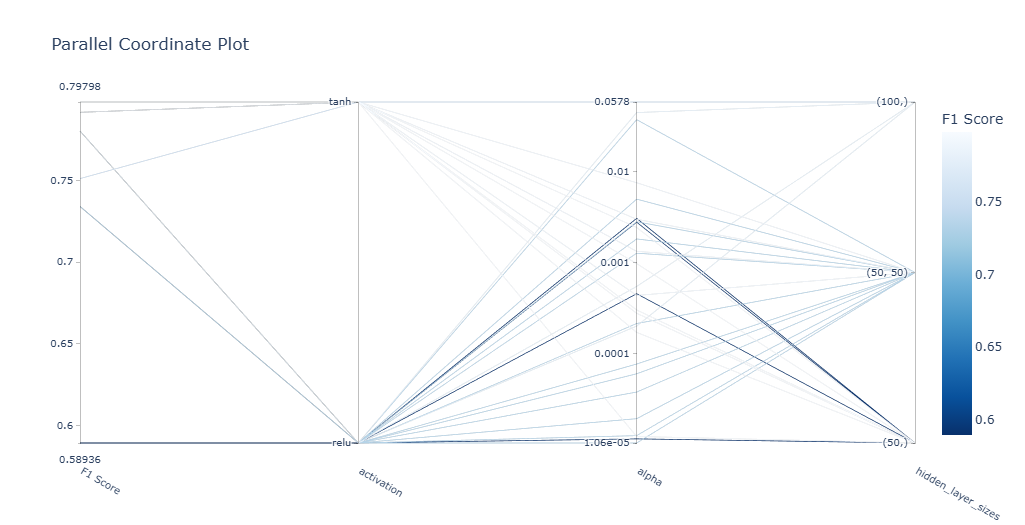

#### Coordenadas paralelas con 50 experimentos
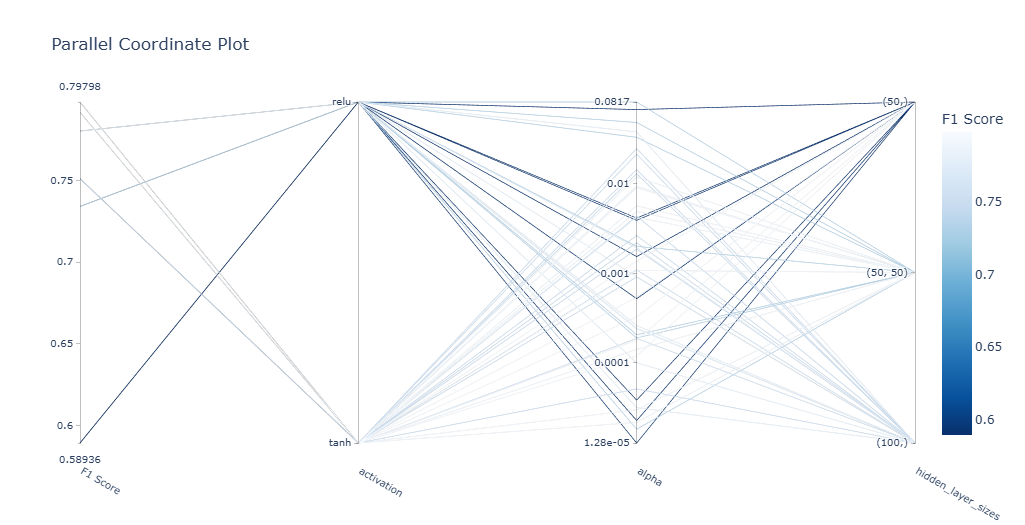

#### Coordenadas paralelas con 100 experimentos
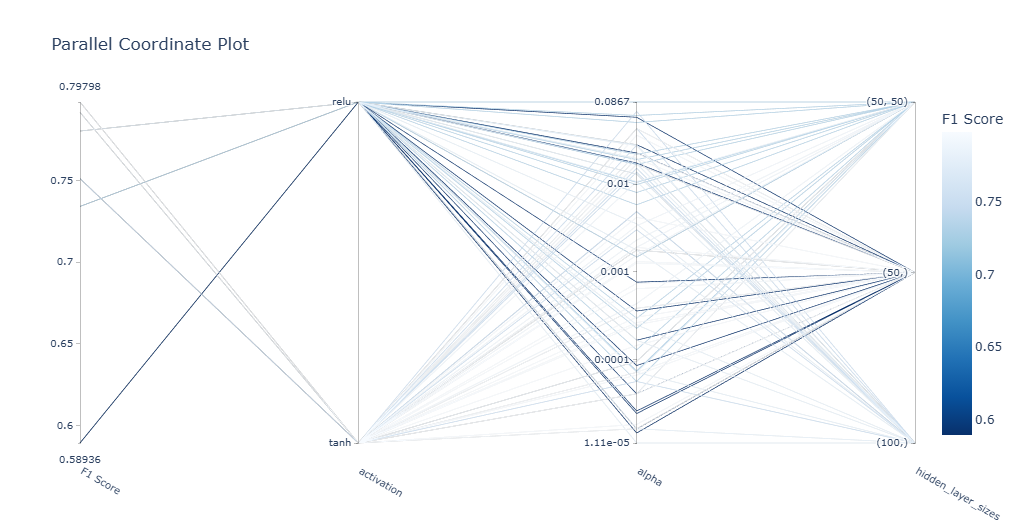

### **Conclusión**

En conclusión, el uso de **Optuna** permite una exploración sistemática y eficiente del espacio de hiperparámetros, superando las limitaciones de las búsquedas manuales. A través de las visualizaciones interactivas, pudimos determinar que:

1.  **Suficiencia de Modelos Simples:** Para el conjunto de datos Iris, las arquitecturas más complejas no garantizan un mejor rendimiento, lo que refuerza el principio de parsimonia en machine learning.
2.  **Importancia de la Regularización:** El parámetro `alpha` demostró ser crítico para la estabilidad del modelo, siendo el principal factor para evitar el sobreajuste independientemente de la profundidad de la red.
3.  **Eficiencia Multiobjetivo:** El Frente de Pareto es una herramienta invaluable para tomar decisiones informadas, permitiéndonos seleccionar modelos que equilibran la precisión (F1 Score) con la eficiencia computacional (Parámetros y FLOPs).

Este flujo de trabajo no solo optimiza el rendimiento técnico, sino que también proporciona una comprensión profunda de la sensibilidad del modelo ante diferentes configuraciones.